# DSA 210 — Data Collection
**Project:** Impact of Global Crises on Financial Markets


In [1]:
# Install libraries (run this cell only once)
!pip install yfinance fredapi pandas matplotlib

In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import os

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:

FRED_API_KEY = "2e22c2185be3bb846c2b2579a5f076f6"

# Crisis event dates
CRISES = {
    "9/11 (2001)":             "2001-09-11",
    "Iraq War (2003)":         "2003-03-20",
    "Financial Crisis (2008)": "2008-09-15",
    "COVID-19 (2020)":         "2020-03-11",
    "Russia-Ukraine (2022)":   "2022-02-24",
    "Israel-Hamas (2023)":     "2023-10-07",
}

# Financial assets to download from Yahoo Finance
TICKERS = {
    "SP500":    "^GSPC",
    "VIX":      "^VIX",
    "Defense":  "ITA",
    "Energy":   "XLE",
    "Health":   "XLV",
    "Tech":     "XLK",
    "Aviation": "JETS",
    "Gold":     "GC=F",
    "Oil":      "BZ=F",
}

# Macroeconomic series from FRED
FRED_SERIES = {
    "Fed_Rate": "FEDFUNDS",
    "CPI":      "CPIAUCSL",
    "Unemploy": "UNRATE",
    "M2":       "M2SL",
}

print('Settings ready.')

Settings ready.


In [4]:
# Step 1: Download financial data (yfinance)

print('Downloading financial data from Yahoo Finance...')

symbols = list(TICKERS.values())

raw = yf.download(
    tickers=symbols,
    start="2000-01-01",
    end="2025-01-01",
    progress=True
)

# Keep only closing prices
prices = raw["Close"].copy()

# Rename columns: "^GSPC" -> "SP500", "^VIX" -> "VIX", etc.
symbol_to_name = {v: k for k, v in TICKERS.items()}
prices.rename(columns=symbol_to_name, inplace=True)

# Drop rows where all values are missing (market holidays)
prices.dropna(how="all", inplace=True)

print(f'Done! {prices.shape[0]} trading days, {prices.shape[1]} assets')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
prices.head()

[*********************100%***********************]  9 of 9 completed

Done! 6293 trading days, 9 assets
Date range: 2000-01-03 to 2024-12-31


Ticker,Oil,Gold,Defense,Aviation,Energy,Tech,Health,SP500,VIX
Date,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,6.655914,20.626381,20.440741,1455.219971,24.209999
2000-01-04,NaN,NaN,NaN,NaN,6.530629,19.579954,19.976898,1399.420044,27.010000
2000-01-05,NaN,NaN,NaN,NaN,6.702901,19.289276,19.797693,1402.109985,26.410000
2000-01-06,NaN,NaN,NaN,NaN,6.961305,18.649794,19.860945,1403.449951,25.730000
2000-01-07,NaN,NaN,NaN,NaN,7.035694,18.975344,20.103409,1441.469971,21.719999


In [5]:
# Step 2: Download macroeconomic data (FRED)
from fredapi import Fred

fred = Fred(api_key="2e22c2185be3bb846c2b2579a5f076f6")

FRED_SERIES = {
    "Fed_Rate": "FEDFUNDS",
    "CPI":      "CPIAUCSL",
    "Unemploy": "UNRATE",
    "M2":       "M2SL",
}

print("Downloading macroeconomic data from FRED...")

all_series = {}
for name, series_id in FRED_SERIES.items():
    print(f"  Downloading {name} ({series_id})...")
    series = fred.get_series(series_id, observation_start="2000-01-01", observation_end="2025-01-01")
    all_series[name] = series

macro = pd.DataFrame(all_series)
macro = macro.resample("D").ffill()
macro = macro.loc["2000-01-01":"2025-01-01"]

print(f"Done! {macro.shape[0]} days, {macro.shape[1]} indicators")
macro.head()

Done! 9133 days, 4 indicators


,Fed_Rate,CPI,Unemploy,M2
2000-01-01,5.45,169.3,4.0,4667.6
2000-01-02,5.45,169.3,4.0,4667.6
2000-01-03,5.45,169.3,4.0,4667.6
2000-01-04,5.45,169.3,4.0,4667.6
2000-01-05,5.45,169.3,4.0,4667.6


In [6]:
# Step 3: Calculate daily returns
# Return = (today's price - yesterday's price) / yesterday's price * 100
# Calculate daily returns
returns = prices.pct_change() * 100
# Drop only rows where ALL values are missing, not just some
returns.dropna(how='all', inplace=True)

print(f'Returns calculated: {returns.shape[0]} days')
returns.head()

Returns calculated: 6292 days


Ticker,Oil,Gold,Defense,Aviation,Energy,Tech,Health,SP500,VIX
Date,,,,,,,,,
2000-01-04,NaN,NaN,NaN,NaN,-1.882320,-5.073245,-2.269205,-3.834467,11.565474
2000-01-05,NaN,NaN,NaN,NaN,2.637912,-1.484569,-0.897061,0.192218,-2.221401
2000-01-06,NaN,NaN,NaN,NaN,3.855111,-3.315223,0.319489,0.095568,-2.574783
2000-01-07,NaN,NaN,NaN,NaN,1.068600,1.745596,1.220808,2.709040,-15.584921
2000-01-10,NaN,NaN,NaN,NaN,-0.834664,3.799058,10.225479,1.118997,-0.046042


In [7]:
# Step 4: Create crisis windows (30 days before and after each crisis)

windows = {}

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    windows[crisis_name] = {
        "crisis_date":  crisis_date,
        "pre_prices":   prices.loc[pre_start  : crisis_date - pd.Timedelta(days=1)],
        "post_prices":  prices.loc[crisis_date : post_end],
        "pre_returns":  returns.loc[pre_start  : crisis_date - pd.Timedelta(days=1)],
        "post_returns": returns.loc[crisis_date : post_end],
    }

    pre_len  = len(windows[crisis_name]["pre_returns"])
    post_len = len(windows[crisis_name]["post_returns"])
    print(f'{crisis_name}: {pre_len} days before, {post_len} days after')

9/11 (2001): 20 days before, 20 days after
Iraq War (2003): 22 days before, 21 days after
Financial Crisis (2008): 19 days before, 23 days after
COVID-19 (2020): 21 days before, 22 days after
Russia-Ukraine (2022): 21 days before, 22 days after
Israel-Hamas (2023): 22 days before, 21 days after


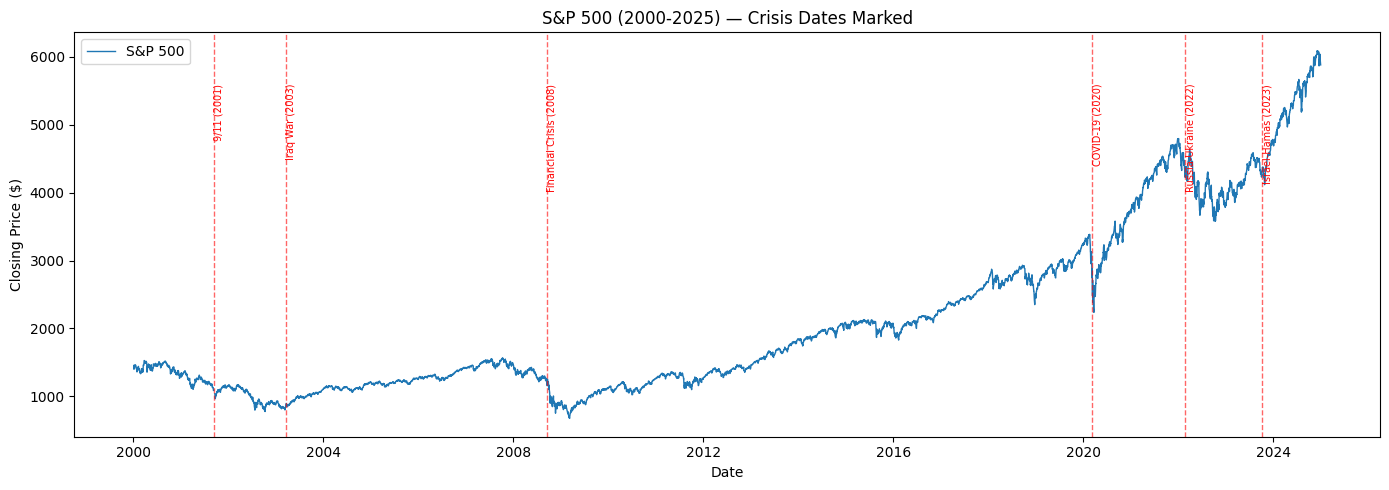

In [8]:
# Step 5: Plot S&P 500 with crisis dates marked

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prices.index, prices["SP500"], color="#1f77b4", linewidth=1, label="S&P 500")

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    ax.axvline(x=crisis_date, color="red", linestyle="--", alpha=0.6, linewidth=1)
    ax.text(crisis_date, prices["SP500"].max() * 0.92, crisis_name,
            rotation=90, fontsize=7, color="red", va="top")

ax.set_title("S&P 500 (2000-2025) — Crisis Dates Marked")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Step 6: Save all data to CSV files

# os.makedirs creates the 'data' folder automatically if it doesn't exist
save_dir = os.path.expanduser("~/Desktop/data")
os.makedirs(save_dir, exist_ok=True)

prices.to_csv(os.path.join(save_dir, "prices.csv"))
returns.to_csv(os.path.join(save_dir, "returns.csv"))
if macro is not None:
    macro.to_csv(os.path.join(save_dir, "macro.csv"))

for crisis_name, w in windows.items():
    safe_name = crisis_name.replace("/", "-").replace(" ", "_")
    w["pre_returns"].to_csv(os.path.join(save_dir, f"{safe_name}_pre.csv"))
    w["post_returns"].to_csv(os.path.join(save_dir, f"{safe_name}_post.csv"))

print("All files saved to:", save_dir)
for f in os.listdir(save_dir):
    print(f"  {f}")

All files saved to: /Users/yagmurcaloglu/Desktop/data
  Russia-Ukraine_(2022)_post.csv
  macro.csv
  COVID-19_(2020)_post.csv
  Israel-Hamas_(2023)_pre.csv
  Iraq_War_(2003)_post.csv
  COVID-19_(2020)_pre.csv
  prices.csv
  Financial_Crisis_(2008)_post.csv
  Russia-Ukraine_(2022)_pre.csv
  Israel-Hamas_(2023)_post.csv
  9-11_(2001)_pre.csv
  9-11_(2001)_post.csv
  Financial_Crisis_(2008)_pre.csv
  returns.csv
  Iraq_War_(2003)_pre.csv


## Summary

| Variable | What it contains |
|---|---|
| `prices` | Daily closing prices for all assets (2000–2025) |
| `returns` | Daily percentage change for all assets |
| `macro` | Interest rate, CPI, unemployment, money supply |
| `windows` | 30-day pre and post data for each crisis |

**Next step: EDA and visualization**